# 03 — CNN-EMG-Fatigue Training

Train `CNNEMGFatigue` on the synthetic dataset. Output: a checkpoint at `results/production-emg-module_best.pt` ready to plug into the NOA concept bottleneck.

In [18]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

DATA_DIR = ROOT / 'data' / 'synthetic'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split

from features import normalize_features
from models import CNNEMGFatigue, EMGDataset, train_one_epoch, evaluate

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

Device: mps


## Load data

In [19]:
X   = np.load(DATA_DIR / 'X.npy')
det = np.load(DATA_DIR / 'det_features.npy')
y   = np.load(DATA_DIR / 'y.npy')
print(f'X: {X.shape}  det: {det.shape}  y: {y.shape}')

X: (1000, 30000)  det: (1000, 5)  y: (1000, 5)


## Train / val split and normalization

80/20 split. Normalization stats fit on train split only, applied to both.

In [20]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
n_train = int(0.8 * len(X))
train_idx, val_idx = idx[:n_train], idx[n_train:]

X_train, X_val     = X[train_idx], X[val_idx]
det_train, det_val = det[train_idx], det[val_idx]
y_train, y_val     = y[train_idx], y[val_idx]

# Fit normalization on train, apply to both
det_train_norm, stats = normalize_features(det_train)
det_val_norm, _       = normalize_features(det_val, stats)

# Save stats alongside checkpoint for inference
(RESULTS_DIR / 'feat_stats.json').write_text(
    json.dumps({k: v.tolist() for k, v in stats.items()}, indent=2)
)

print(f'Train: {len(X_train)}  Val: {len(X_val)}')

Train: 800  Val: 200


## DataLoaders

In [21]:
BATCH = 32

train_ds = EMGDataset(X_train, det_train_norm, y_train)
val_ds   = EMGDataset(X_val,   det_val_norm,   y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Train batches: 25  Val batches: 7


## Instantiate model

In [22]:
model = CNNEMGFatigue(n_det_features=5, dropout=0.3).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

# Smoke test: one forward pass
with torch.no_grad():
    x_test = torch.zeros(2, 1, X.shape[1]).to(DEVICE)
    d_test = torch.zeros(2, 5).to(DEVICE)
    out = model(x_test, d_test)
print(f'Output shape: {out.shape}  (expect [2, 5])')

Trainable parameters: 482,405
Output shape: torch.Size([2, 5])  (expect [2, 5])


## Training loop

Adam + cosine annealing LR. Early stopping on val loss (patience 10).

In [23]:
EPOCHS    = 60
LR        = 3e-4
PATIENCE  = 10
CKPT_PATH = RESULTS_DIR / 'production-emg-module_best.pt'

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses = [], []
best_val, patience_count = float('inf'), 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    vl_loss = evaluate(model, val_loader, DEVICE)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)

    if vl_loss < best_val:
        best_val = vl_loss
        patience_count = 0
        torch.save({'model_state': model.state_dict(), 'epoch': epoch, 'val_loss': best_val}, CKPT_PATH)
    else:
        patience_count += 1

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}  train={tr_loss:.5f}  val={vl_loss:.5f}  best={best_val:.5f}')

    if patience_count >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break

print(f'\nBest val MSE: {best_val:.5f}  checkpoint → {CKPT_PATH}')

Epoch   5  train=0.00339  val=0.00449  best=0.00113
Epoch  10  train=0.00247  val=0.00068  best=0.00068
Epoch  15  train=0.00227  val=0.00072  best=0.00061
Epoch  20  train=0.00173  val=0.00062  best=0.00055
Epoch  25  train=0.00176  val=0.00059  best=0.00052
Epoch  30  train=0.00138  val=0.00052  best=0.00049
Epoch  35  train=0.00143  val=0.00050  best=0.00048
Epoch  40  train=0.00144  val=0.00050  best=0.00047
Epoch  45  train=0.00119  val=0.00045  best=0.00045
Epoch  50  train=0.00131  val=0.00044  best=0.00044
Epoch  55  train=0.00127  val=0.00044  best=0.00044
Epoch  60  train=0.00127  val=0.00043  best=0.00043

Best val MSE: 0.00043  checkpoint → /Users/yejin/neonatal-ml-learning/projects/emg-fatigue/results/production-emg-module_best.pt


## Learning curves

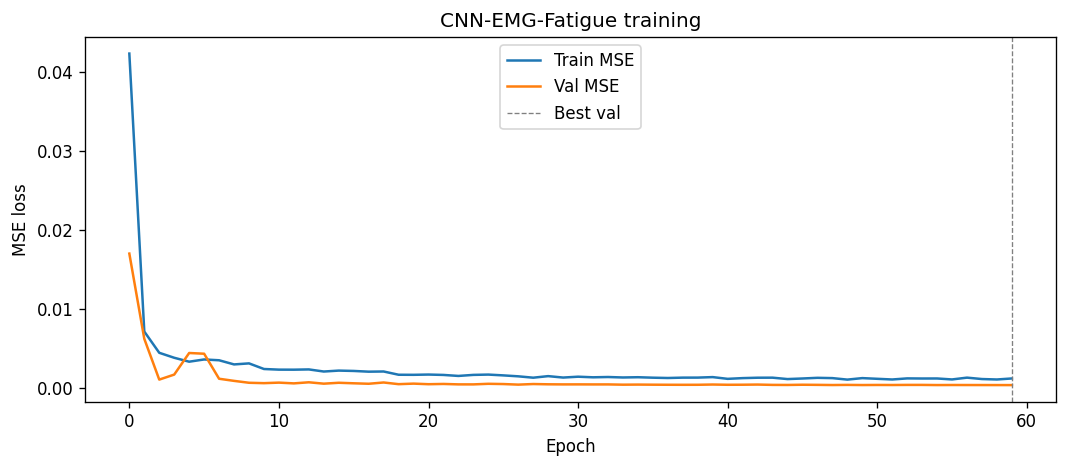

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train MSE')
ax.plot(val_losses,   label='Val MSE')
ax.axvline(val_losses.index(min(val_losses)), color='gray', ls='--', lw=0.8, label='Best val')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('CNN-EMG-Fatigue training')
ax.legend()
plt.tight_layout()

## Per-output evaluation on val set

Load best checkpoint and report MSE and MAE per concept bottleneck output.

In [25]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for x, d, yb in val_loader:
        preds = model(x.to(DEVICE), d.to(DEVICE)).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())

preds = np.vstack(all_preds)
true  = np.vstack(all_true)

output_names = ['fatigue_prob', 'resp_effort', 'mdf_slope_norm', 'spectral_comp', 'entropy']
print(f"{'Output':<22}  {'MSE':>8}  {'MAE':>8}")
print('-' * 42)
for name, p, t in zip(output_names, preds.T, true.T):
    mse = np.mean((p - t) ** 2)
    mae = np.mean(np.abs(p - t))
    print(f"{name:<22}  {mse:8.5f}  {mae:8.5f}")

Output                       MSE       MAE
------------------------------------------
fatigue_prob             0.00041   0.01598
resp_effort              0.00019   0.01114
mdf_slope_norm           0.00109   0.02637
spectral_comp            0.00027   0.01230
entropy                  0.00023   0.01203


## Predicted vs true — scatter per output


Checkpoint saved: /Users/yejin/neonatal-ml-learning/projects/emg-fatigue/results/production-emg-module_best.pt
CNN-EMG-Fatigue ready for integration into NOA concept bottleneck.


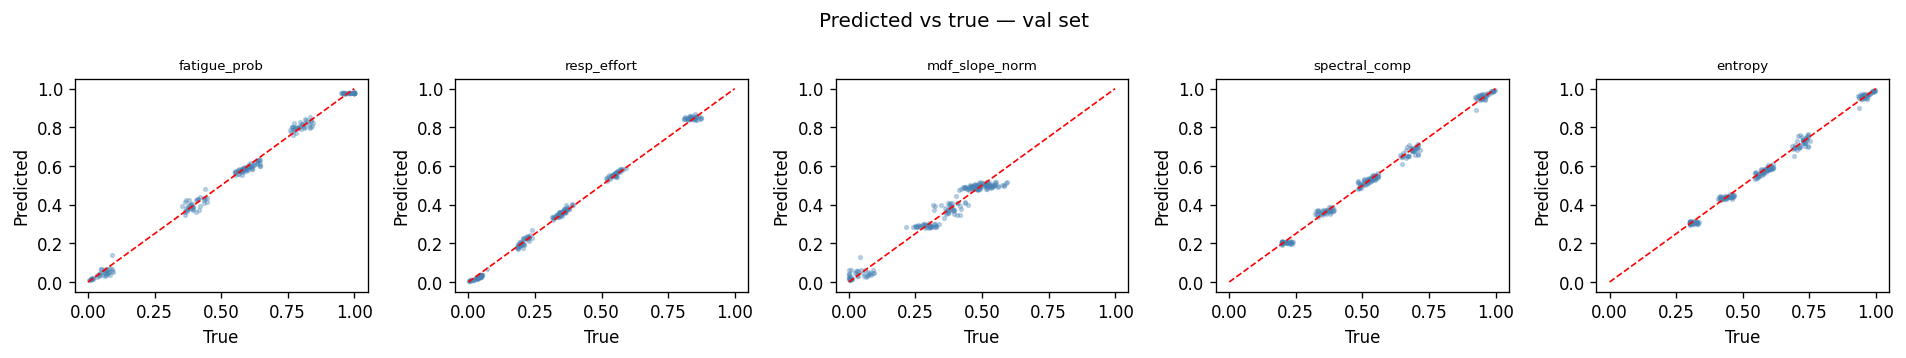

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, name, p, t in zip(axes, output_names, preds.T, true.T):
    ax.scatter(t, p, s=5, alpha=0.3, color='steelblue')
    ax.plot([0, 1], [0, 1], 'r--', lw=1)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
fig.suptitle('Predicted vs true — val set')
plt.tight_layout()

print(f'\nCheckpoint saved: {CKPT_PATH}')
print('CNN-EMG-Fatigue ready for integration into NOA concept bottleneck.')